In [72]:
import seaborn as sns 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [73]:
df=pd.read_csv("/Users/mayurimamdi/Downloads/customer_subscription_churn_usage_patterns.csv")

In [74]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [75]:
df.shape

(2800, 10)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


In [77]:
df['plan_type'].value_counts()

plan_type
Premium     944
Standard    933
Basic       923
Name: count, dtype: int64

In [78]:
df['monthly_fee'].value_counts()

monthly_fee
699    944
399    933
199    923
Name: count, dtype: int64

In [79]:
df['churn'].value_counts()

churn
Yes    1605
No     1195
Name: count, dtype: int64

In [80]:
df['signup_year']=df['signup_date'].str.split('-').str[0].astype(int)

In [81]:
df['signup_month']=df['signup_date'].str.split('-').str[1].astype(int)

In [82]:
df['day']=df['signup_date'].str.split('-').str[2].astype(int)

In [83]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,signup_year,signup_month,day
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes,2023,4,15
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes,2023,8,27
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes,2023,10,12
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes,2023,12,11
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes,2023,2,14


## EDA

In [84]:
#df['churn']=df['churn'].map({'Yes':1, 'No':0})

In [85]:
#df['plan_type']=df['plan_type'].map({'Premium':3, 'Standard':2, 'Basic':1})

In [86]:
df['signup_year'].unique()

array([2023, 2024])

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
 10  signup_year             2800 non-null   int64  
 11  signup_month            2800 non-null   int64  
 12  day                     2800 non-null   int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 284.5+ KB


In [88]:
df['signup_year'].unique()

array([2023, 2024])

In [89]:
res=df.groupby('signup_month')['churn'].value_counts().reset_index(name='count')


<Axes: xlabel='signup_month', ylabel='count'>

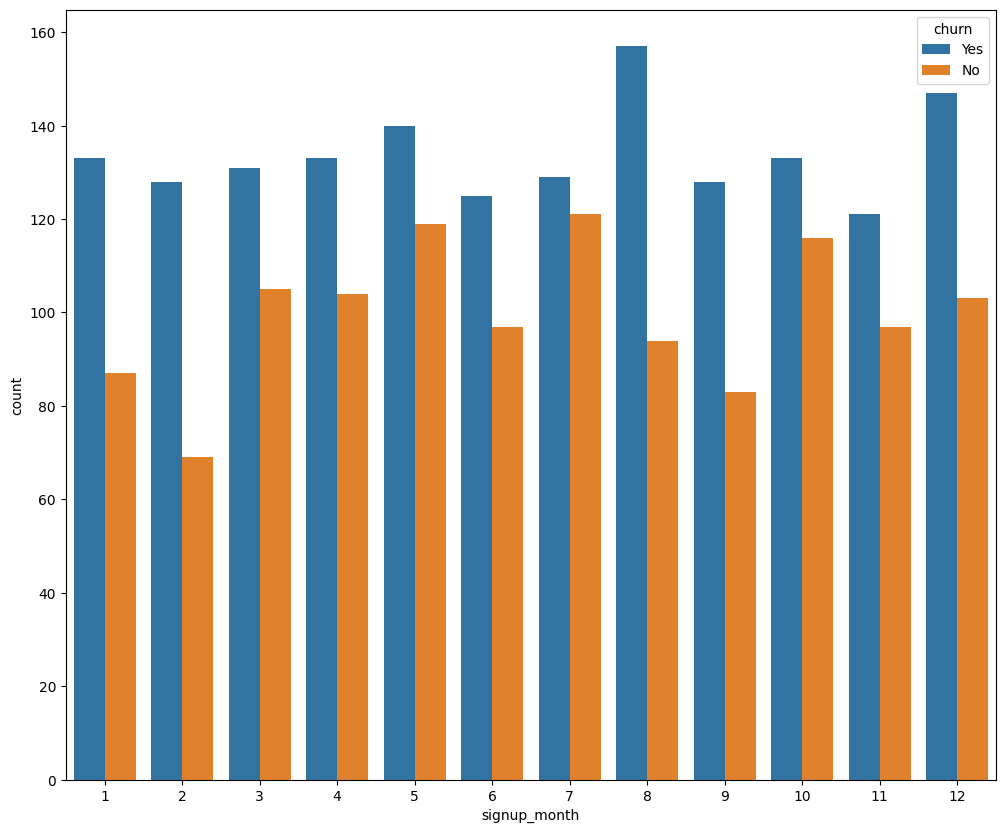

In [90]:
plt.figure(figsize=(12,10))
sns.barplot(data=res, x='signup_month',y='count',hue='churn')

#### Observation: August month is when the churn was more, and in february the churn was less

In [91]:
year_df=df.groupby('signup_year')['churn'].value_counts().reset_index(name='count')

<Axes: xlabel='signup_year', ylabel='count'>

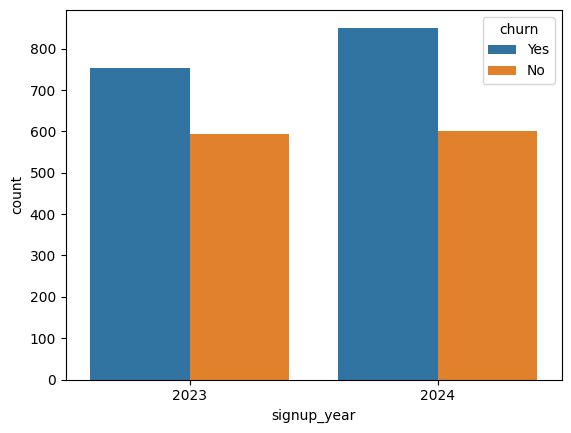

In [92]:
sns.barplot(data=year_df, x='signup_year', y='count', hue='churn' )

#### There is more churn in 2024 than 2023

In [93]:
df['signup_month'].unique()

array([ 4,  8, 10, 12,  2,  1,  3, 11,  9,  6,  7,  5])

In [94]:
df[(df['signup_month']==2) &(df['signup_year']==2024)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,2,Yes,58
1,2,No,27


In [95]:
df[(df['signup_month']==8) &(df['signup_year']==2024)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,8,Yes,91
1,8,No,51


In [96]:
df[(df['signup_month']==2) &(df['signup_year']==2023)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,2,Yes,70
1,2,No,42


In [97]:
df[(df['signup_month']==8) &(df['signup_year']==2023)].groupby('signup_month')['churn'].value_counts().reset_index(name='count')

,signup_month,churn,count
0,8,Yes,66
1,8,No,43


#### Observation : august month in year 2024 is when the churn was more and also lowest churn was in february year 2024

In [98]:
days=df[(df['signup_month']==2) &(df['signup_year']==2024)].groupby('day')['churn'].value_counts().reset_index(name='count')

/var/folders/ph/wg0wr1gs4qs24s_3z3tp0pj80000gn/T/ipykernel_49891/2093922542.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=days, x='day', y='count',hue='churn', ci=None)


<Axes: xlabel='day', ylabel='count'>

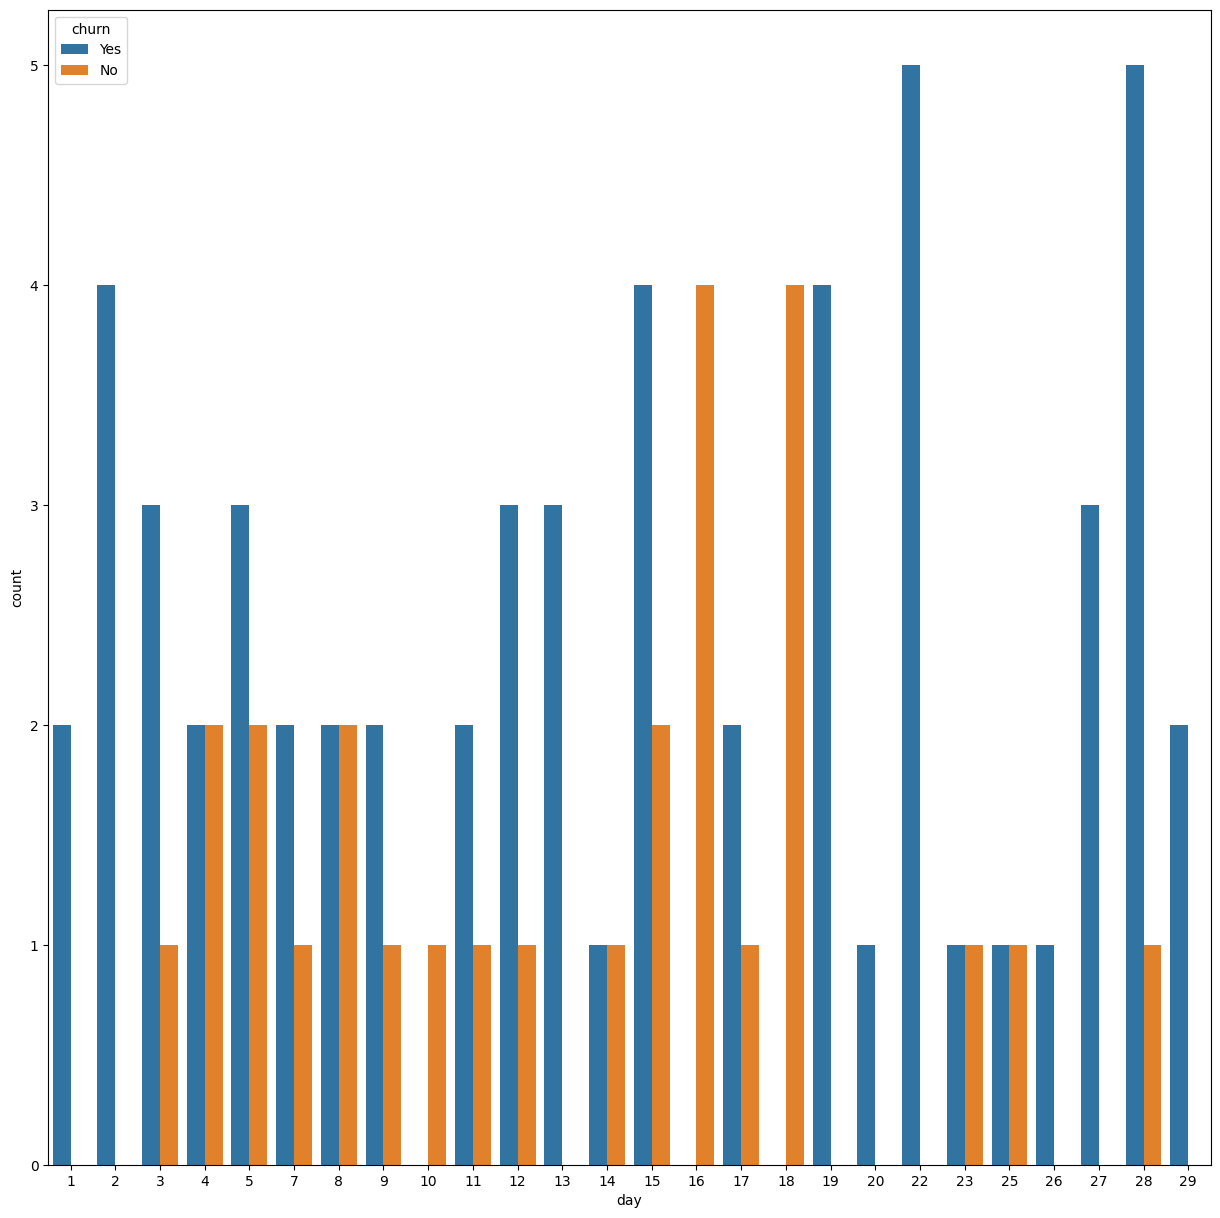

In [99]:
plt.figure(figsize=(15,15))
sns.barplot(data=days, x='day', y='count',hue='churn', ci=None)

In [100]:
aug_days=df[(df['signup_month']==8) & (df['signup_year']==2024)].groupby('day')['churn'].value_counts().reset_index(name='count')

/var/folders/ph/wg0wr1gs4qs24s_3z3tp0pj80000gn/T/ipykernel_49891/1123012493.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=aug_days, x='day', y='count', hue='churn', ci=None)


<Axes: xlabel='day', ylabel='count'>

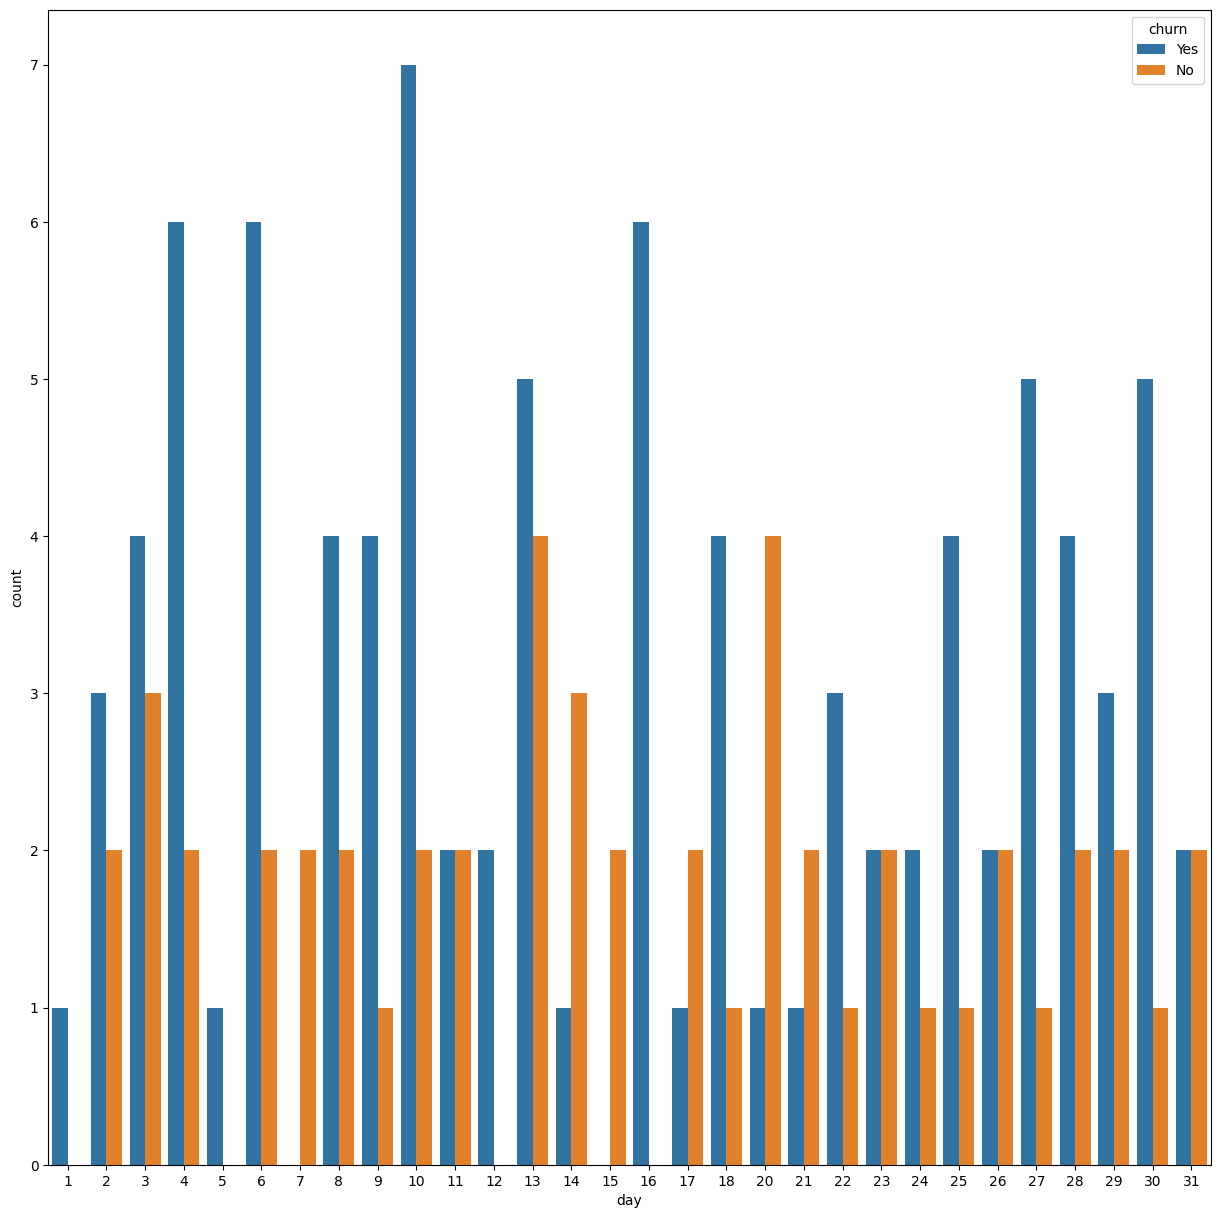

In [101]:
plt.figure(figsize=(15,15))
sns.barplot(data=aug_days, x='day', y='count', hue='churn', ci=None)

## Feature Engineering 

In [102]:
df['churn']=df['churn'].map({'Yes':1,'No':0})

In [103]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,signup_year,signup_month,day
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,1,2023,4,15
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,1,2023,8,27
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,1,2023,10,12
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,1,2023,12,11
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,1,2023,2,14


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   int64  
 10  signup_year             2800 non-null   int64  
 11  signup_month            2800 non-null   int64  
 12  day                     2800 non-null   int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 284.5+ KB


In [105]:
df['plan_type'].unique()

array(['Premium', 'Basic', 'Standard'], dtype=object)

In [107]:
df['plan_type']=df['plan_type'].map({'Basic':0,'Standard':1,'Premium':2})

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   int64  
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   int64  
 10  signup_year             2800 non-null   int64  
 11  signup_month            2800 non-null   int64  
 12  day                     2800 non-null   int64  
dtypes: float64(1), int64(11), object(1)
memory usage: 284.5+ KB


In [111]:
df.drop(columns=['user_id','signup_date'], axis=1, inplace=True)

In [112]:
df.head()

,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,signup_year,signup_month,day
0,2,699,1.1,4,1,8,14,1,2023,4,15
1,2,699,2.6,6,0,35,1,1,2023,8,27
2,2,699,14.3,8,3,2,14,1,2023,10,12
3,0,199,17.6,5,2,11,9,1,2023,12,11
4,0,199,9.8,5,2,6,38,1,2023,2,14


In [113]:
df.isnull().sum()

plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
signup_year               0
signup_month              0
day                       0
dtype: int64

In [114]:
df.duplicated().sum()

np.int64(0)

NO Duplicate values or Null values

### Lets start with the Feature selection 

In [115]:
cor=df.corr()

<Axes: >

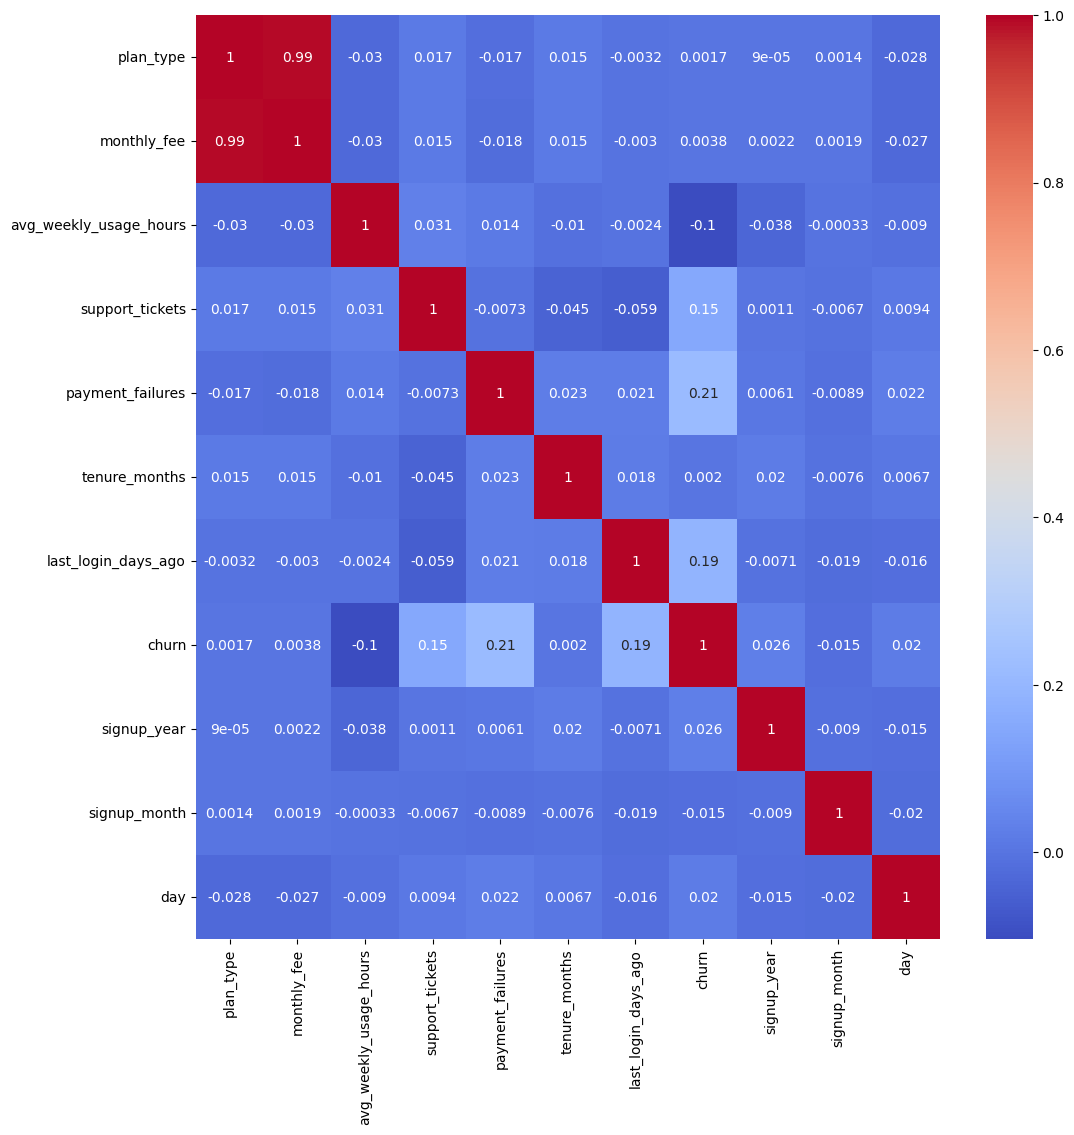

In [117]:
plt.figure(figsize=(12,12))
sns.heatmap(cor, annot=True, cmap='coolwarm')

In [119]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [120]:
corr_feature=correlation(df.drop('churn', axis=1), threshold=0.8)
corr_feature

{'monthly_fee'}

In [121]:
df_reduced=df.drop(corr_feature, axis=1)

In [122]:
df_reduced

,plan_type,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,signup_year,signup_month,day
0,2,1.1,4,1,8,14,1,2023,4,15
1,2,2.6,6,0,35,1,1,2023,8,27
2,2,14.3,8,3,2,14,1,2023,10,12
3,0,17.6,5,2,11,9,1,2023,12,11
4,0,9.8,5,2,6,38,1,2023,2,14
...,...,...,...,...,...,...,...,...,...,...
2795,1,6.7,1,1,21,59,0,2023,3,10
2796,1,11.0,4,0,6,4,0,2024,11,20
2797,1,11.0,0,4,22,59,0,2024,8,13
2798,2,15.0,3,4,25,20,0,2024,5,23


<Axes: >

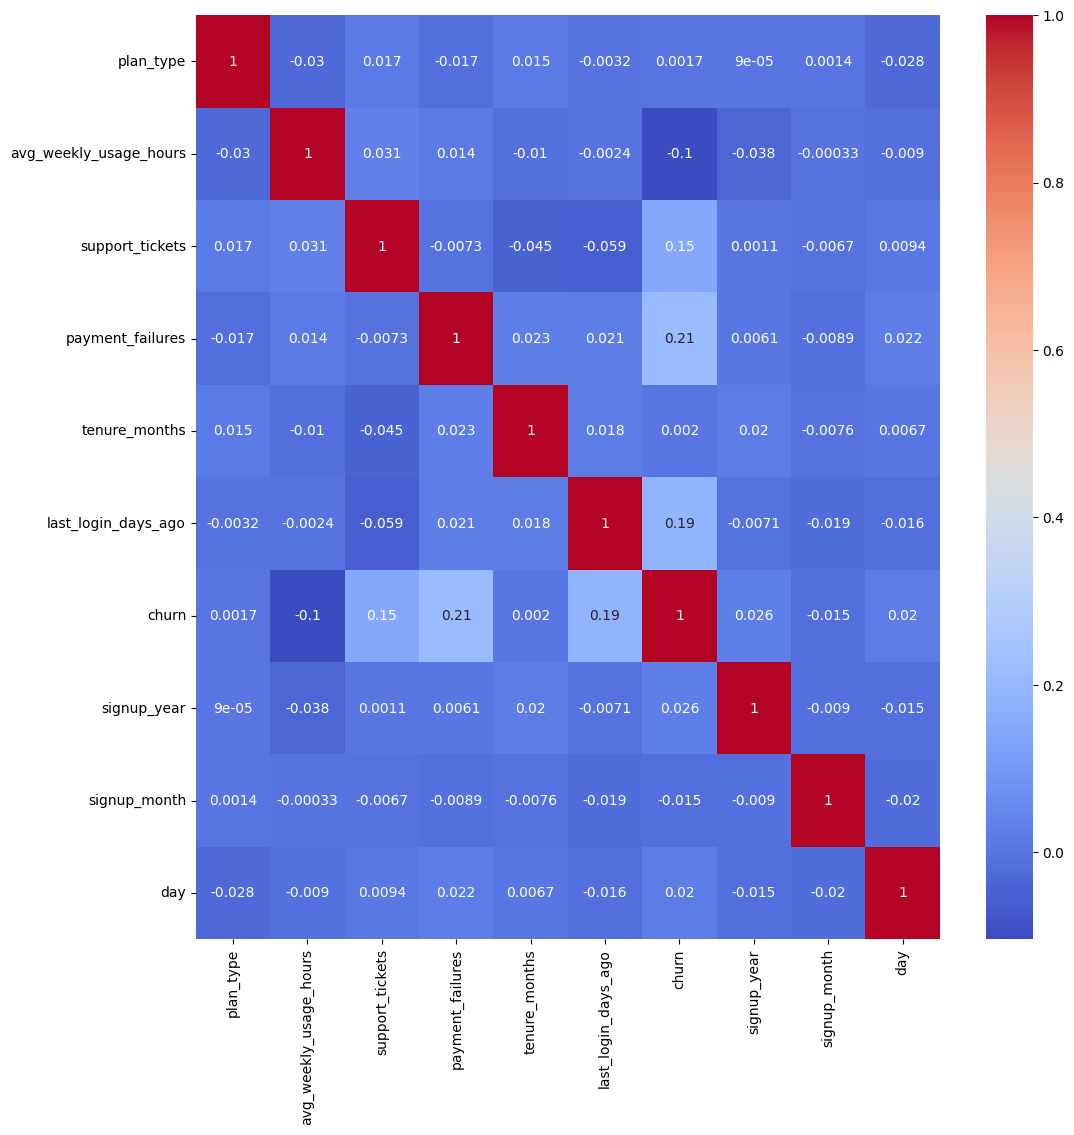

In [124]:
plt.figure(figsize=(12,12))
sns.heatmap(df_reduced.corr(), annot=True, cmap='coolwarm')

In [125]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
X_reduced = df_reduced.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)


In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(max_iter=1000)

# Before feature selection
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("F1 before:", f1_score(y_test, y_pred))

# After feature selection
model.fit(Xr_train, yr_train)
y_pred_r = model.predict(Xr_test)
print("F1 after:", f1_score(yr_test, y_pred_r))


F1 before: 0.7254038179148311
F1 after: 0.7254038179148311


### well, They look the same 

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

sel_feature=SelectKBest()